# Task1: Tối ưu hóa hàm số với thuật toán Hill Climbing
**Môn học:** Trí tuệ nhân tạo  
**Phương pháp:** Lập trình hướng đối tượng (OOP)
## Yêu cầu 1 (0.5 điểm)
**Vẽ mặt phẳng 3D minh họa hàm $f$ và đường đi của thuật toán.**

---

## Yêu cầu 2 (2.0 điểm)
**Cài đặt thuật toán Hill Climbing để tìm vị trí $(x, y)$ có giá trị $f$ lớn nhất, bắt đầu từ $O(0, 0)$.**
**Các ý cần giải quyết:**
1.  Đề xuất cách xác định lân cận tốt nhất ngay lập tức với độ phức tạp $O(1)$
2.  Đề xuất cách kiểm soát kích thước bước nhảy (khoảng cách giữa trạng thái hiện tại và lân cận được chọn).
3.  Đề xuất cách xử lý trường hợp không còn lân cận nào tốt hơn (kẹt tại cực đại cục bộ).

---

## Yêu cầu 3 (0.5 điểm)
**Tổ chức chương trình theo mô hình Hướng đối tượng (OOP), đảm bảo mã nguồn ngắn gọn và hợp lý.**




### Tóm tắt triển khai Hill Climbing

Thuật toán Hill Climbing theo mô hình OOP gồm 4 lớp:
- `State`: đại diện cho trạng thái (x, y) và sinh 8 lân cận trong O(1)
- `Problem`: tạo hàm mục tiêu f(x, y) bằng sympy và lambdify
- `HillClimbing`: cài đặt Multi-Step Radius Search với các step size [0.1, 0.3, 0.7]
- `Visualizer`: vẽ đồ thị 3D, vẽ đường đi màu đỏ, đánh dấu điểm bắt đầu và kết thúc.

### Thuật toán Multi-Step Radius Search
Thay vì chỉ dùng một bước nhảy cố định, thuật toán sử dụng nhiều bán kính khác nhau để sinh lân cận.  
Tại mỗi bước, thuật toán:
1. Sinh lân cận với từng bán kính r trong radius_list
2. Gom toàn bộ lân cận
3. Chọn hàng xóm có giá trị lớn nhất
4. Nếu tốt hơn thì di chuyển; nếu không thì dừng

Chiến lược này cho phép thuật toán thoát khỏi cực trị cục bộ và khám phá không gian tốt hơn.

Bắt đầu tại: (0.0000, 0.0000), f = 2.00000
Bước 1: Di chuyển đến (0.7000, -0.7000), f = 2.21961
Bước 2: Di chuyển đến (1.4000, -1.4000), f = 2.51916
Bước 3: Di chuyển đến (2.1000, -2.1000), f = 2.87309
Bước 4: Di chuyển đến (2.8000, -2.8000), f = 3.23264
Bước 5: Di chuyển đến (3.5000, -3.5000), f = 3.51547
Bước 6: Di chuyển đến (3.5000, -4.2000), f = 3.67325
Bước 7: Di chuyển đến (3.5000, -4.5000), f = 3.70639
Bước 8: Di chuyển đến (3.5000, -4.6000), f = 3.71114
Bước 9: Di chuyển đến (3.5000, -4.7000), f = 3.71234
--- Dừng tại Bước 10: Không tìm thấy lân cận tốt hơn (Cực đại cục bộ).

===== KẾT QUẢ =====
Điểm cực đại: State(3.50, -4.70)
Giá trị cực đại f = 3.712340018363046
Tổng số bước di chuyển: 9


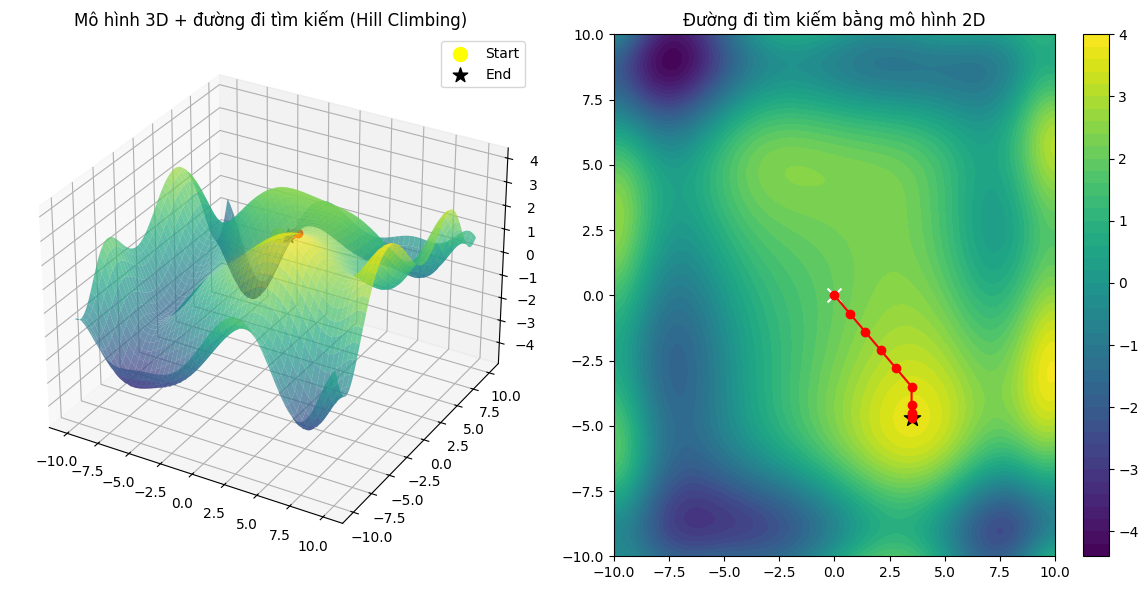

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import symbols, sin, cos
from sympy.utilities.lambdify import lambdify

# ======================================================
# 1. CLASS STATE
# ======================================================
class State:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def get_neighbors(self, step_size):
        """Sinh 8 láng giềng – O(1)."""
        directions = [
            (step_size, 0), (-step_size, 0),
            (0, step_size), (0, -step_size),
            (step_size, step_size), (step_size, -step_size),
            (-step_size, step_size), (-step_size, -step_size)
        ]
        return [State(self.x + dx, self.y + dy) for dx, dy in directions]

    def __repr__(self):
        return f"State({self.x:.2f}, {self.y:.2f})"


# ======================================================
# 2. CLASS PROBLEM
# ======================================================
class Problem:
    def __init__(self):
        x, y = symbols("x y")
        self.f_sym = (
            sin(x/4) + cos(y/4)
            - sin(x*y/16)
            + cos(x**2/16)
            + sin(y**2/16)
        )
        self.f = lambdify((x, y), self.f_sym, "numpy")

    def value(self, s: State):
        return self.f(s.x, s.y)


# ======================================================
# 3. MULTI-STEP RADIUS HILL CLIMBING
# ======================================================
class HillClimbing:
    def __init__(self, radius_list, max_iter=1000):
        self.radius_list = radius_list
        self.max_iter = max_iter

    def solve(self, problem: Problem, initial_state: State):
        current = initial_state
        path = [current]
        print(f"Bắt đầu tại: ({current.x:.4f}, {current.y:.4f}), f = {problem.value(current):.5f}")
        for _ in range(self.max_iter):
            current_val = problem.value(current)

            # MULTI-STEP search
            neighbors = []
            for r in self.radius_list:
                neighbors.extend(current.get_neighbors(step_size=r))

            # chọn hàng xóm tốt nhất – O(1)
            best_neighbor = max(neighbors, key=lambda s: problem.value(s))
            best_val = problem.value(best_neighbor)

            # nếu không có hàng xóm tốt hơn: dừng
            if best_val <= current_val:
                print(f"--- Dừng tại Bước {_+1}: Không tìm thấy lân cận tốt hơn (Cực đại cục bộ).")
                break

            current = best_neighbor
            path.append(current)
            # BỔ SUNG: In ra quá trình di chuyển
            print(f"Bước {_+1}: Di chuyển đến ({current.x:.4f}, {current.y:.4f}), f = {best_val:.5f}")
        return current, path


# ======================================================
# 4. VISUALIZER
# ======================================================
class Visualizer:
    def __init__(self, problem: Problem):
        self.problem = problem

    def draw(self, path):
        x = np.linspace(-10, 10, 150)
        y = np.linspace(-10, 10, 150)
        X, Y = np.meshgrid(x, y)
        Z = self.problem.f(X, Y)

        px = [s.x for s in path]
        py = [s.y for s in path]
        pz = [self.problem.value(s) for s in path]

        fig = plt.figure(figsize=(12, 6))
        ax = fig.add_subplot(1, 2, 1, projection='3d')

        ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.7)
        ax.plot(px, py, pz, color="red", linewidth=3, marker="o")
        ax.scatter(px[0], py[0], pz[0], color="yellow", s=100, label="Start")
        ax.scatter(px[-1], py[-1], pz[-1], color="black", s=120, marker="*", label="End")

        ax.set_title("Mô hình 3D + đường đi tìm kiếm (Hill Climbing)")
        ax.legend()

        # 2D heatmap
        ax2 = fig.add_subplot(1, 2, 2)
        contour = ax2.contourf(X, Y, Z, 50, cmap="viridis")
        plt.colorbar(contour)
        ax2.plot(px, py, color="red", marker="o")
        ax2.scatter(px[0], py[0], color="white", marker="x", s=100)
        ax2.scatter(px[-1], py[-1], color="black", marker="*", s=150)
        ax2.set_title("Đường đi tìm kiếm bằng mô hình 2D")

        plt.tight_layout()
        plt.show()

# ======================================================
# 5. MAIN
# ======================================================
if __name__ == "__main__":
    problem = Problem()

    # Bắt đầu từ O(0,0)
    start = State(0, 0)

    hill = HillClimbing(radius_list=[0.1, 0.3, 0.7])
    final_state, path = hill.solve(problem, start)

    print("\n===== KẾT QUẢ =====")
    print("Điểm cực đại:", final_state)
    print("Giá trị cực đại f =", problem.value(final_state))
    print("Tổng số bước di chuyển:", len(path) - 1)

    viz = Visualizer(problem)
    viz.draw(path)
